# 01 · Exploratory Data Analysis
Report section: *Dataset description* + *EDA* (mandatory, brief item c).

Covers class balance (C1), the red-corner confound (C2), and feature distributions. Correlations and the leakage sanity check (C3) follow in Section 5.

In [1]:
# Make src/ importable from notebooks/
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.load import load_clean
from src.plotting import save_fig, order_weight_classes, use_report_style, nice_label
use_report_style()   # larger fonts so figures stay legible in the report

## 1. Load data
`data/raw/...` (see `docs/DATASETS.md`). Leakage-safe build lives in `src/data/`.


In [2]:
df, y = load_clean()
winner = y.str.split('-').str[0]      # 'Red' / 'Blue'
method = y.str.split('-').str[1]      # 'KO' / 'SUB' / 'DEC'
print(f'{len(df)} fights, {y.nunique()} classes, {df.shape[1]} raw columns')
y.value_counts()

6911 fights, 6 classes, 111 raw columns


Red-DEC     1974
Blue-DEC    1454
Red-KO      1242
Blue-KO      981
Red-SUB      775
Blue-SUB     485
Name: count, dtype: int64

## 2. Class balance & target
Winner / method-of-victory distribution; weight-class & stance breakdowns.


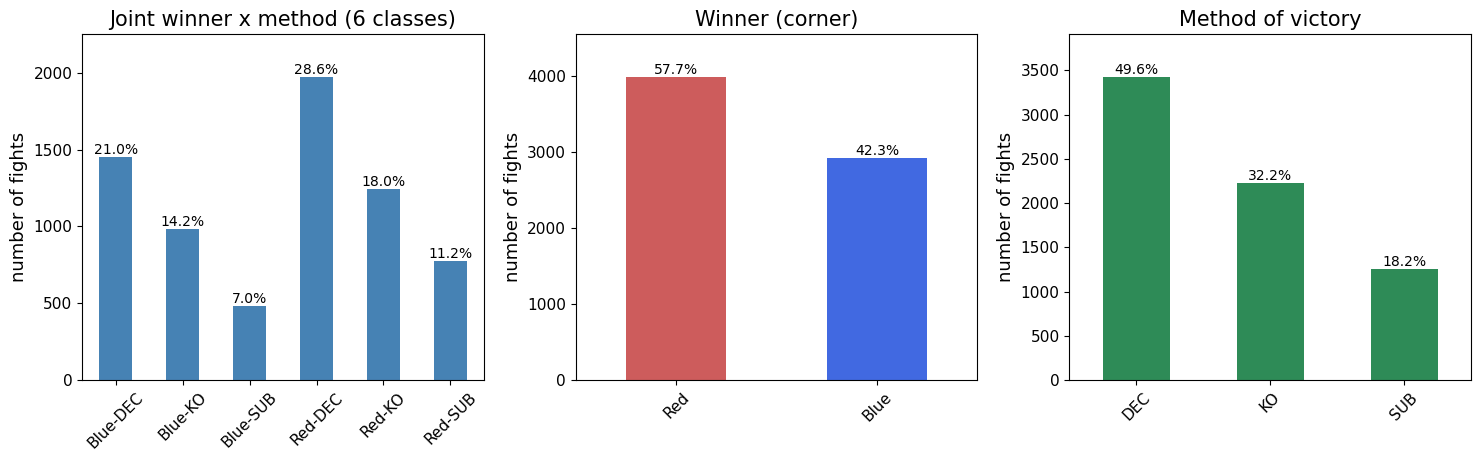

imbalance: Red-DEC (1974) vs Blue-SUB (485) = 4.1x
red wins 57.7% of fights (the skew we symmetrize away for modelling)


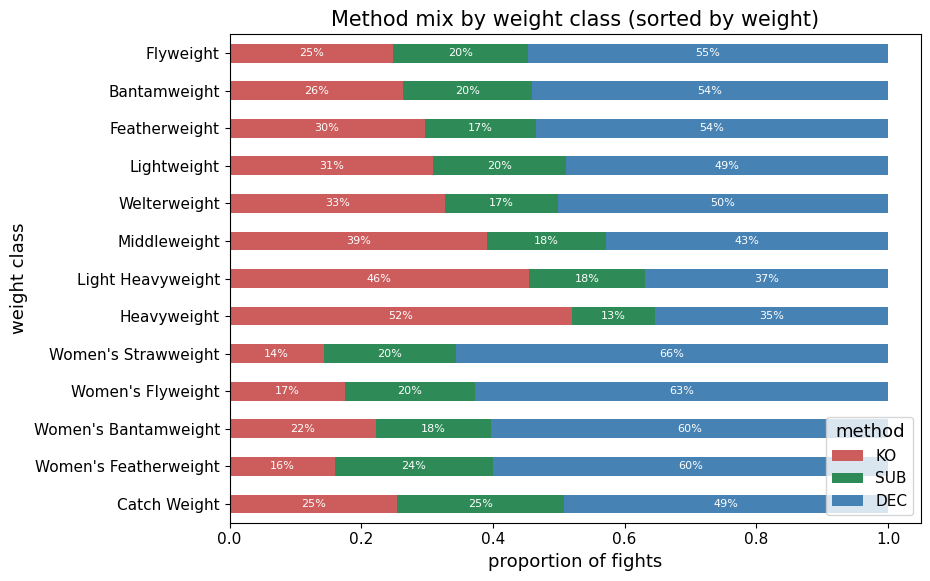

In [3]:
# --- class balance: the 6 joint classes, plus the winner and method views ---
def pct_labels(ax, total):
    """Write each bar's share of the total as a label above it."""
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{h/total:.1%}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=10)

n = len(y)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
y.value_counts().sort_index().plot.bar(ax=ax[0], color='steelblue', title='Joint winner x method (6 classes)')
winner.value_counts().plot.bar(ax=ax[1], color=['indianred', 'royalblue'], title='Winner (corner)')
method.value_counts().plot.bar(ax=ax[2], color='seagreen', title='Method of victory')
for a in ax:
    a.tick_params(axis='x', rotation=45); a.set_ylabel('number of fights')
    pct_labels(a, n); a.margins(y=0.14)
plt.tight_layout(); save_fig('class_balance'); plt.show()

vc = y.value_counts()
print(f'imbalance: {vc.idxmax()} ({vc.max()}) vs {vc.idxmin()} ({vc.min()}) = {vc.max()/vc.min():.1f}x')
print(f'red wins {(winner == "Red").mean():.1%} of fights (the skew we symmetrize away for modelling)')

# --- method mix by weight class (sorted by weight: men's divisions first, then women's) ---
order = order_weight_classes(df['weight_class'].unique())
ct = pd.crosstab(df['weight_class'], method, normalize='index')[['KO', 'SUB', 'DEC']]
ct = ct.reindex(order[::-1])   # reversed so the barh reads lightest->heaviest top-to-bottom
ax2 = ct.plot.barh(stacked=True, figsize=(9.5, 6), color=['indianred', 'seagreen', 'steelblue'],
                   title='Method mix by weight class (sorted by weight)')
for p in ax2.patches:                       # write each segment's share inside it
    w = p.get_width()
    if w > 0.04:
        ax2.annotate(f'{w:.0%}', (p.get_x() + w / 2, p.get_y() + p.get_height() / 2),
                     ha='center', va='center', fontsize=8, color='white')
ax2.set_ylabel('weight class'); plt.xlabel('proportion of fights'); plt.legend(title='method', loc='lower right')
plt.tight_layout(); save_fig('method_by_weightclass'); plt.show()

**What these plots show.** The target is imbalanced: decisions dominate (Red-DEC alone is ~29% of all fights versus ~7% for Blue-SUB, a ~4x spread). The winner split (Red 57.7% / Blue 42.3%) is the red-corner skew dissected next; the method split (DEC 49.6% > KO 32.2% > SUB 18.2%) means a model that blindly predicts "decision" already gets ~50% on method. This is why we report macro-F1 and log-loss alongside accuracy, and it foreshadows the confusion matrix concentrating on the decision classes. The method-by-weight chart confirms the expected physical pattern: KO share rises with weight (heavyweights finish by knockout far more than flyweights), while lighter divisions go to decision more often.

## 3. The red-corner confound (the differentiator)
Red wins ~58% of fights, but "red" is systematically assigned to the favourite. We show the raw red win-rate, then condition on who the market favours: once we know the favourite, the corner colour adds almost nothing. This is why we **symmetrize corners** for modelling, and measure an "always-red" baseline only on the original corners.

raw P(red wins)              = 0.577
red is the favourite in        59.5% of fights
P(red wins | red favourite)   = 0.696
P(red wins | blue favourite)  = 0.404
P(favourite wins, any corner) = 0.655


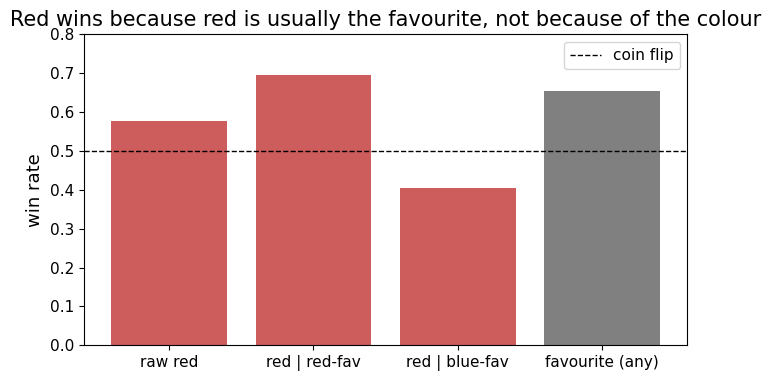

In [4]:
# raw red advantage
red_wr = (winner == 'Red').mean()

# 'favourite' = the corner with the more negative American moneyline
red_fav = df['R_odds'] < df['B_odds']
p_red_red_fav  = (winner[red_fav]  == 'Red').mean()
p_red_blue_fav = (winner[~red_fav] == 'Red').mean()
fav_won = (red_fav & (winner == 'Red')) | (~red_fav & (winner == 'Blue'))
fav_wr = fav_won.mean()

print(f'raw P(red wins)              = {red_wr:.3f}')
print(f'red is the favourite in        {red_fav.mean():.1%} of fights')
print(f'P(red wins | red favourite)   = {p_red_red_fav:.3f}')
print(f'P(red wins | blue favourite)  = {p_red_blue_fav:.3f}')
print(f'P(favourite wins, any corner) = {fav_wr:.3f}')

bars = {'raw red': red_wr, 'red | red-fav': p_red_red_fav,
        'red | blue-fav': p_red_blue_fav, 'favourite (any)': fav_wr}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bars.keys(), bars.values(), color=['indianred', 'indianred', 'indianred', 'grey'])
ax.axhline(0.5, ls='--', c='k', lw=1, label='coin flip')
ax.set_ylabel('win rate'); ax.set_ylim(0, 0.8); ax.legend()
ax.set_title('Red wins because red is usually the favourite, not because of the colour')
plt.tight_layout(); save_fig('red_corner_confound'); plt.show()

**What this plot shows.** Red's raw 57.7% win rate looks like a colour advantage but is not. Conditioning on the betting favourite collapses it: red wins ~70% when it is the favourite and only ~40% when it is the underdog, while the favourite wins ~65.5% *regardless of corner*. So "red" is just a proxy for "favourite" - a selection effect, not a causal one. This is exactly why we symmetrize corners for modelling (forcing a 50/50 base rate so the model cannot exploit the shortcut) and only ever score the naive always-red baseline on the original corners.

## 4. Feature distributions
Spread of the key pre-fight difference features (red - blue). (Correlations and the leakage sanity check follow in Section 5.)

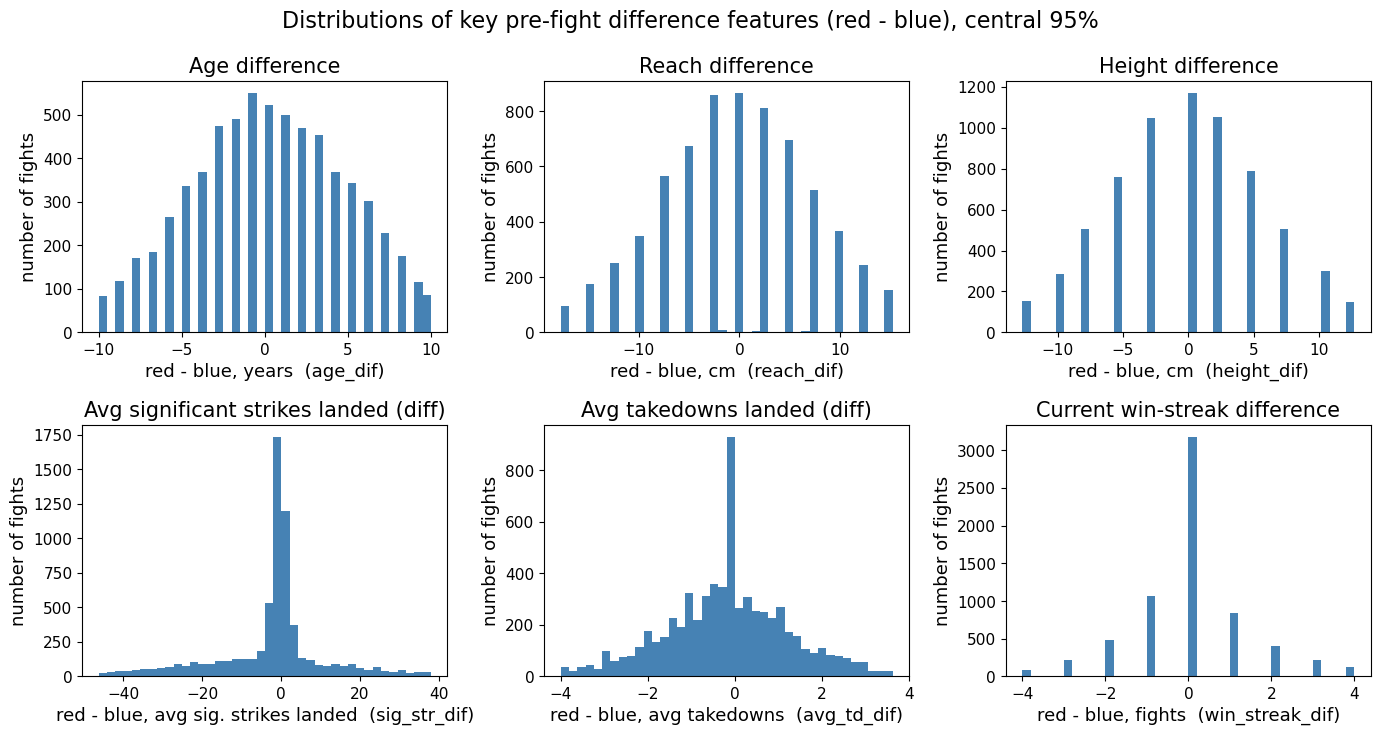

In [5]:
# distributions of a few key pre-fight difference features (red - blue), with units.
# A handful of rows carry impossible values (e.g. reach_dif = -188 cm), so we crop the
# x-axis to the central 95% [2.5%, 97.5%] - the view, not the data, is trimmed.
feat_units = [('age_dif', 'years'), ('reach_dif', 'cm'), ('height_dif', 'cm'),
              ('sig_str_dif', 'avg sig. strikes landed'), ('avg_td_dif', 'avg takedowns'),
              ('win_streak_dif', 'fights')]
feat_units = [(c, u) for c, u in feat_units if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for (col, unit), ax in zip(feat_units, axes.ravel()):
    s = df[col].dropna()
    lo, hi = s.quantile(0.025), s.quantile(0.975)
    ax.hist(s, bins=40, range=(lo, hi), color='steelblue')
    ax.set_title(nice_label(col, with_raw=False))
    ax.set_xlabel(f'red - blue, {unit}  ({col})'); ax.set_ylabel('number of fights')
fig.suptitle('Distributions of key pre-fight difference features (red - blue), central 95%')
plt.tight_layout(); save_fig('feature_distributions'); plt.show()

**What these plots show.** The difference features are roughly symmetric and centred on zero, as they must be once corners are balanced: neither corner is systematically taller, older, or busier. Spreads are modest (most fights fall within ~+/-13 cm of reach/height and ~+/-10 years of age). The raw columns do carry a few physically impossible values (a -188 cm reach difference in 3 rows), which is why the axes are cropped to the central 95%; these are data-entry errors, and a reason the difference features still benefit from the train-only imputation in the pipeline.

## 5. Correlations & leakage sanity check (C3)
Multicollinearity among the key difference features (matters for LDA/QDA), then a pre-fight integrity check: career aggregates must come from prior fights only, so debutants should have empty priors.

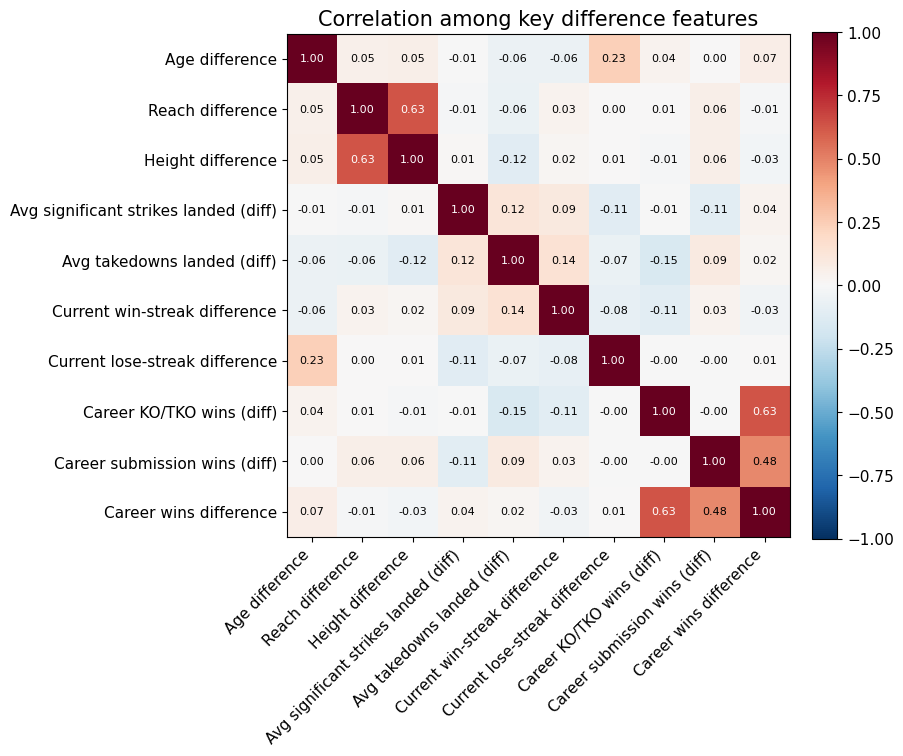

In [6]:
# correlation among the key difference features (a multicollinearity check for LDA/QDA)
key = ['age_dif', 'reach_dif', 'height_dif', 'sig_str_dif', 'avg_td_dif',
       'win_streak_dif', 'lose_streak_dif', 'ko_dif', 'sub_dif', 'win_dif']
key = [c for c in key if c in df.columns]
corr = df[key].corr()
labels = [nice_label(c, with_raw=False) for c in key]   # human labels (raw names in the importance plot)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(key))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(key))); ax.set_yticklabels(labels)
for i in range(len(key)):
    for j in range(len(key)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Correlation among key difference features')
plt.tight_layout(); save_fig('feature_correlations'); plt.show()

**What this heatmap shows.** The difference features are largely independent: most pairwise correlations sit near zero, with two intuitive exceptions - reach vs height (0.63: taller fighters reach further) and career KOs vs total wins (0.63: finishers pile up wins). Low multicollinearity is reassuring for the covariance-based baselines (LDA/QDA), which degrade when inputs are strongly redundant, and it confirms the features are not just restating one underlying quantity.

In [7]:
# Pre-fight integrity: a fighter's career-average stats must come from PRIOR fights only,
# so a debutant (no prior UFC record) should have empty priors. If the current bout leaked
# in, debutants would already show stats.
for pref in ['R', 'B']:
    avg_cols = [c for c in df.columns if 'avg' in c.lower() and c.startswith(f'{pref}_')]
    deb = (df[f'{pref}_wins'] + df[f'{pref}_losses']) == 0
    nan_deb = df.loc[deb, avg_cols].isna().mean().mean()
    nan_exp = df.loc[~deb, avg_cols].isna().mean().mean()
    print(f'{pref} corner: {deb.sum():4d} debutants | career-avg missing: '
          f'debut {nan_deb:.0%} vs experienced {nan_exp:.0%}')

print('\nExperienced fighters have complete priors (0% missing); debutants are mostly empty')
print('=> aggregates are genuinely PRE-fight (the current bout is not baked in). Leakage-safe.')
print('(the ~25% of UFC-debutants that do show stats had pre-UFC fights seeding their averages.)')

R corner:  431 debutants | career-avg missing: debut 75% vs experienced 0%
B corner: 1071 debutants | career-avg missing: debut 71% vs experienced 0%

Experienced fighters have complete priors (0% missing); debutants are mostly empty
=> aggregates are genuinely PRE-fight (the current bout is not baked in). Leakage-safe.
(the ~25% of UFC-debutants that do show stats had pre-UFC fights seeding their averages.)


**What this check shows.** Career-average columns are ~75% empty for debutants (no prior UFC fights) but 0% empty for experienced fighters. If the bout being predicted had leaked into a fighter's aggregates, debutants would already show stats - they do not. So the aggregates are genuinely pre-fight and the dataset is leakage-safe. (The ~25% of debutants that do show stats had pre-UFC fights seeding their averages.)

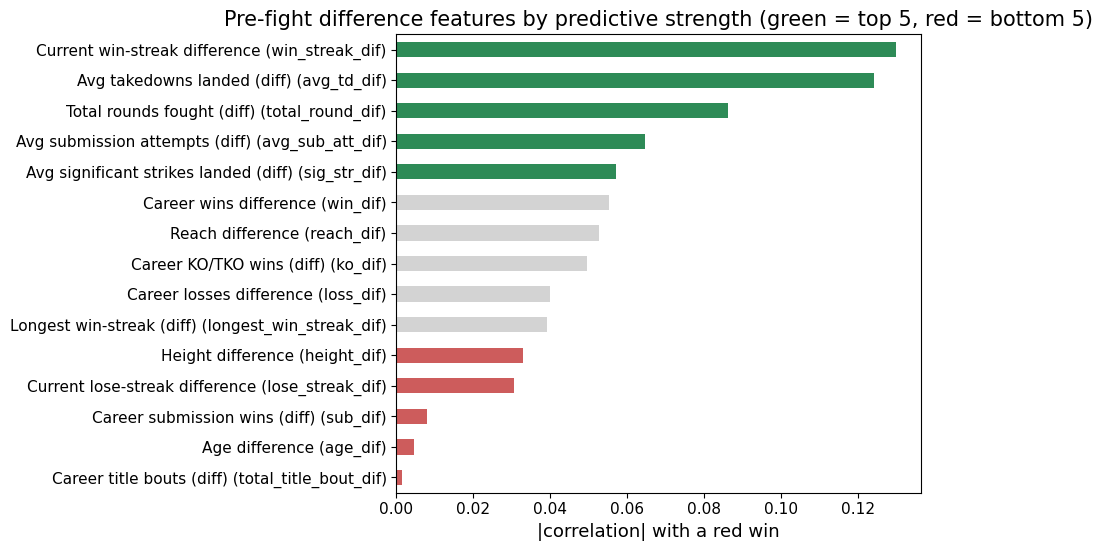

most predictive: ['sig_str_dif', 'avg_sub_att_dif', 'total_round_dif', 'avg_td_dif', 'win_streak_dif']
least predictive: ['total_title_bout_dif', 'age_dif', 'sub_dif', 'lose_streak_dif', 'height_dif']


In [8]:
# Feature importance: |corr| of each difference feature with the winner (most vs least predictive)
red = (winner == 'Red').astype(int)
dif = [c for c in df.columns if c.endswith('_dif')]
imp = df[dif].apply(lambda col: col.corr(red)).abs().sort_values()
hi5, lo5 = imp.iloc[-5], imp.iloc[4]   # top-5 / bottom-5 thresholds
colors = ['seagreen' if v >= hi5 else ('indianred' if v <= lo5 else 'lightgrey') for v in imp]

imp_plot = imp.copy()
imp_plot.index = [nice_label(c) for c in imp.index]   # human labels, raw name in parens
fig, ax = plt.subplots(figsize=(9.5, max(5, 0.38 * len(imp))))
imp_plot.plot.barh(ax=ax, color=colors)
ax.set_xlabel('|correlation| with a red win')
ax.set_title('Pre-fight difference features by predictive strength (green = top 5, red = bottom 5)')
plt.tight_layout(); save_fig('feature_importance'); plt.show()
print('most predictive:', imp.tail(5).index.tolist())
print('least predictive:', imp.head(5).index.tolist())

**What this plot shows, and why only difference features.** Each bar is the absolute correlation of one *difference* feature with a red win. Two takeaways: (1) the ranking is led by recent form (win-streak), grappling (avg takedowns), and experience (rounds fought), all ahead of the much-discussed reach and age near the bottom; and (2) every correlation is small (max ~0.13), the first quantitative sign that achievable accuracy is limited.

Why only the 15 `_dif` columns and not all 111? The raw frame is **15 difference features + 80 absolute `R_`/`B_` columns + 16 others**. We rank only the differences because they are the symmetric, interpretable "edge" quantities the models key on. The 80 absolute columns are mostly the *same* stats split per corner (`R_age` and `B_age`, whose difference *is* `age_dif`), so they are redundant here, and because the modelling symmetrizes corners, an absolute column's correlation with "red wins" is ~0 by construction. The remaining 16 are non-features: identifiers (names, date, location), the betting **odds** (kept benchmark-only so the model can't relearn the market), and categoricals (`weight_class`, `stance`, `gender`) that are one-hot encoded rather than correlated as one number. So the plot already shows the full set of informative, non-redundant numeric features; the grey bars in the middle are just the difference features that are neither top-5 nor bottom-5 (15 total = 5 + 5 + 5).